# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [ ]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [ ]:
df['month_year']

,month_year
datetime,
2011-01-01 00:00:00,2011-01
2011-01-01 01:00:00,2011-01
2011-01-01 02:00:00,2011-01
2011-01-01 03:00:00,2011-01
2011-01-01 04:00:00,2011-01
...,...
2012-12-19 19:00:00,2012-12
2012-12-19 20:00:00,2012-12
2012-12-19 21:00:00,2012-12


In [ ]:
avg_count_by_month = df.groupby(df.month_year)['count'].mean()

In [ ]:
avg_count_by_month

,count
month_year,
2011-01,54.645012
2011-02,73.641256
2011-03,86.849776
2011-04,111.026374
2011-05,174.809211
2011-06,196.877193
2011-07,203.614035
2011-08,182.666667
2011-09,174.622517


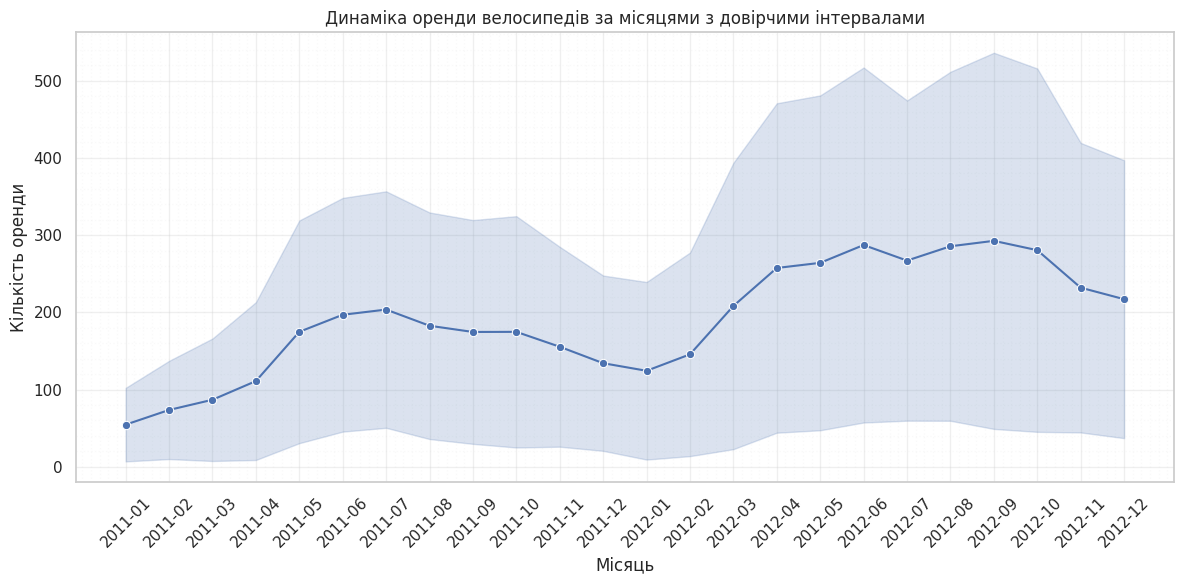

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(df, x='month_year', y='count', marker='o', errorbar='sd')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')

# Додаємо сітку з різними стилями
plt.grid(True, which='major', linestyle='-', alpha=0.3)
plt.grid(True, which='minor', linestyle=':', alpha=0.1)
plt.minorticks_on()

plt.xticks(rotation=45)
plt.tight_layout();

**Відповідь:** В які місяці найбільша невизначеність в даних? - Найбільша невизначеність в даних спостерігається з березня 2012 по листопад 2012, хоча в ці місяці найбільші значення по кількості аренди велосипедів, але є багато значень які є значно більші і значно менші (дуже широкий довірчий інтервал). На мою думку, на це впливають погодні умови, сезонність та вихідні/святкові дні або індивідуальні переваги орендаторів.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

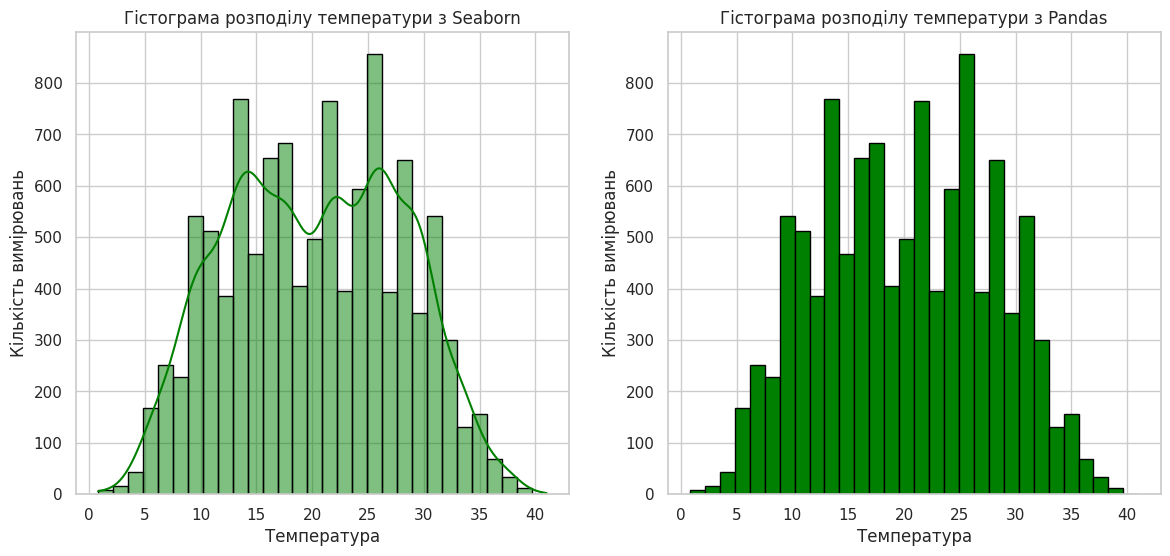

In [ ]:
# Дані
x = np.linspace(0, 10, 100)

plt.figure(figsize=(14, 6))

# Графік 1 - Гістограма розподілу температури з Seaborn
plt.subplot(1, 2, 1)

sns.histplot(data=df,
             x='temp',
             kde=True,
             bins=30,
             color='green',
             edgecolor='black'
)

plt.title('Гістограма розподілу температури з Seaborn')
plt.xlabel('Температура')
plt.ylabel('Кількість вимірювань')

# Графік 2 - Гістограма розподілу температури з Pandas
plt.subplot(1, 2 , 2)
plt.hist(df['temp'],
         bins=30,
         color='green',
         edgecolor='black'
)
plt.title('Гістограма розподілу температури з Pandas')
plt.xlabel('Температура')
plt.ylabel('Кількість вимірювань')
plt.show()

**Відповідь:** Яка візуальна різниця між Pandas та Seaborn гістограмами? - Візуалізація з Seaborn більш прозора та приваблива, чим з Pandas.
Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами? - KDE (Kernel Density Estimate) — це крива щільності розподілу, показує загальну форму розподілу без прив’язки до конкретних стовпчиків (де крива вище - там значень більше, де нижче - значень менше, піки - найтиповіші значення). Маємо 2/3 піки на графіку.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

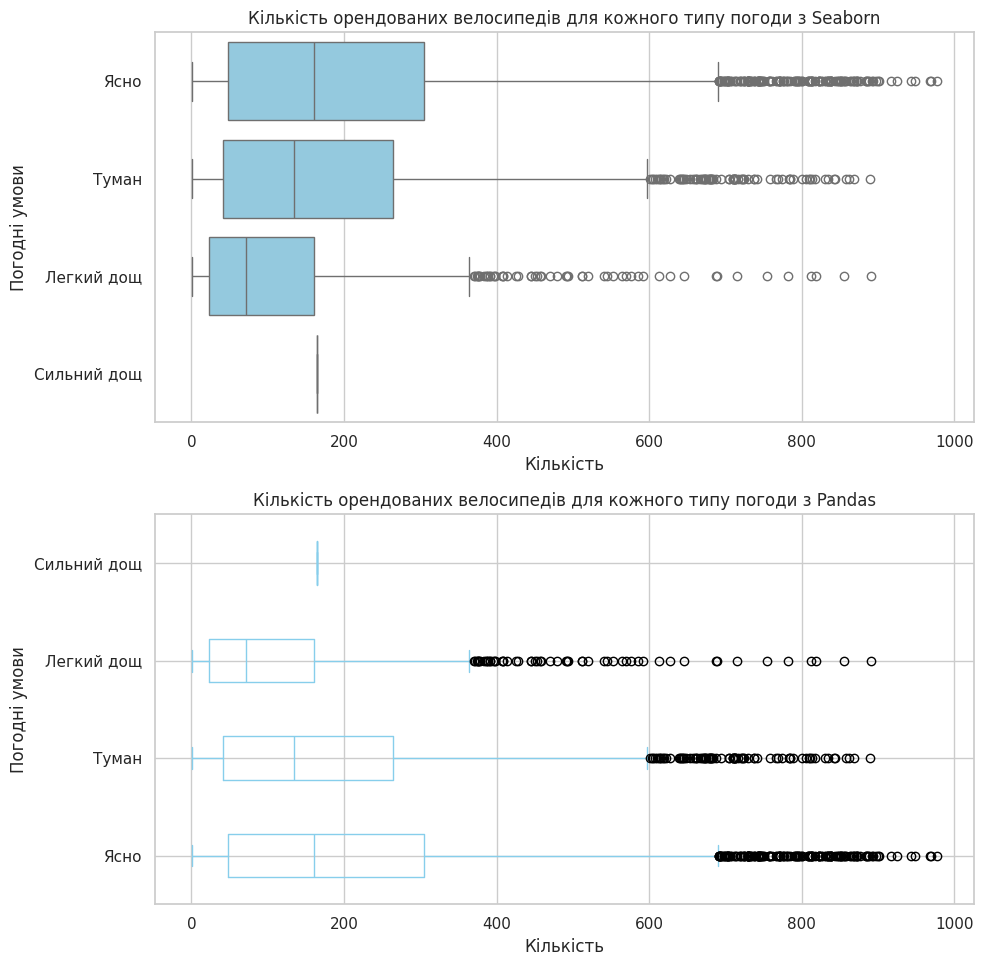

In [ ]:
weather_type = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Графік 1 - Box Plot з Seaborn
sns.boxplot(
    data=df,
    x='count',
    y='weather',
    orient='h',
    color='skyblue',
    ax=axes[0]
)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(weather_type)
axes[0].set_title('Кількість орендованих велосипедів для кожного типу погоди з Seaborn')
axes[0].set_xlabel('Кількість')
axes[0].set_ylabel('Погодні умови')

# Графік 2 - Box Plot з Pandas

df.boxplot(
     column='count',
     by='weather',
     color='skyblue',
     #grid = False,
     vert=False,
     ax=axes[1]
)
axes[1].set_yticks(range(1, 5))
axes[1].set_yticklabels(weather_type)
axes[1].set_title('Кількість орендованих велосипедів для кожного типу погоди з Pandas')
axes[1].set_xlabel('Кількість')
axes[1].set_ylabel('Погодні умови')

# Видаляємо автоматичний заголовок
plt.suptitle('')
# Відступ між графіками
plt.tight_layout()

plt.show();





**Відповідь:** Яка візуальна різниця між Pandas та Seaborn бокс-плотами?:
Вони показують одну й ту саму статистику, але відрізняються оформленням і налаштуваннями. У Seaborn стиль більш сучасніший і більш естетичний.
Більш приємна палітра кольорів, кращі відступи та читабельність.
Легко додати stripplot. Призначений для побудови презентаційних графіків. У Pandas прості лінії, мінімальне оформлення, схожий на більш «технічний» графік для аналізу.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [ ]:
correlation = df[['season', 'weather', 'temp', 'atemp','humidity','windspeed','count','casual','registered']].corr()




In [ ]:
correlation

,season,weather,temp,atemp,humidity,windspeed,count,casual,registered
season,1.000000,0.008879,0.258689,0.264744,0.190610,-0.147121,0.163439,0.096758,0.164011
weather,0.008879,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.128655,-0.135918,-0.109340
temp,0.258689,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.394454,0.467097,0.318571
atemp,0.264744,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.389784,0.462067,0.314635
humidity,0.190610,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.317371,-0.348187,-0.265458
windspeed,-0.147121,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.101369,0.092276,0.091052
count,0.163439,-0.128655,0.394454,0.389784,-0.317371,0.101369,1.000000,0.690414,0.970948
casual,0.096758,-0.135918,0.467097,0.462067,-0.348187,0.092276,0.690414,1.000000,0.497250
registered,0.164011,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.970948,0.497250,1.000000


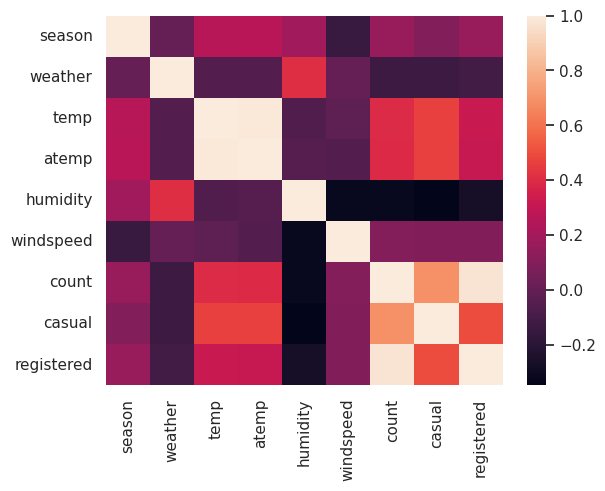

In [ ]:
sns.heatmap(correlation);

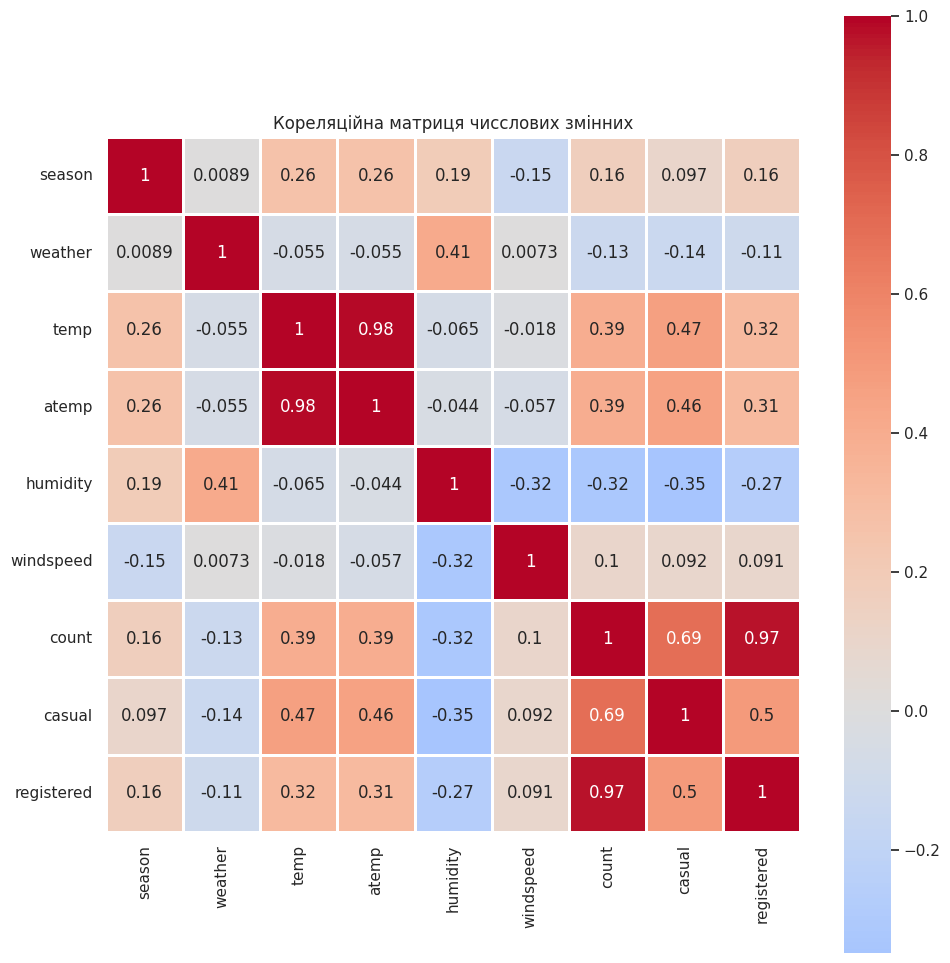

In [ ]:
plt.figure(figsize=(10, 10))

sns.heatmap(correlation, annot=True, cmap='coolwarm',
            center=0,
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця чисслових змінних')
plt.tight_layout()
plt.show()

**Відповідь:** **1.** Які змінні найсильніше корелюють із загальною кількістю оренди (count)?
Для цього набору даних найсильніший позитивний зв'язок із count мають:
registered — дуже сильна позитивна кореляція (≈ 0.97);
casual — сильна позитивна кореляція (≈ 0.69);
temp і atemp — помірна або сильна позитивна кореляція (≈ 0.4–0.5).
Зі збільшенням температури та кількості зареєстрованих користувачів загальна кількість оренд велосипедів зростає.
**2.** Яка кореляція між temp та atemp? Чому?
Між temp та atemp спостерігається сильна позитивна кореляція (≈ 0.98–0.99).
Відчутна температура розраховується на основі фактичної температури та додаткових факторів (вологість, вітер), тому обидві змінні майже дублюють одна одну і змінюються практично одночасно.
**3.** Які змінні мають негативну кореляцію?
У цьому наборі даних негативну кореляцію мають:
humidity - count — вища вологість часто супроводжується меншою кількістю оренд;
weather - count — погіршення погодних умов зменшує кількість оренд;
weather - casual та weather - registered — у погану погоду люди рідше користуються велосипедами.
Від'ємна кореляція показує, що при збільшенні однієї змінної інша має тенденцію зменшуватися.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


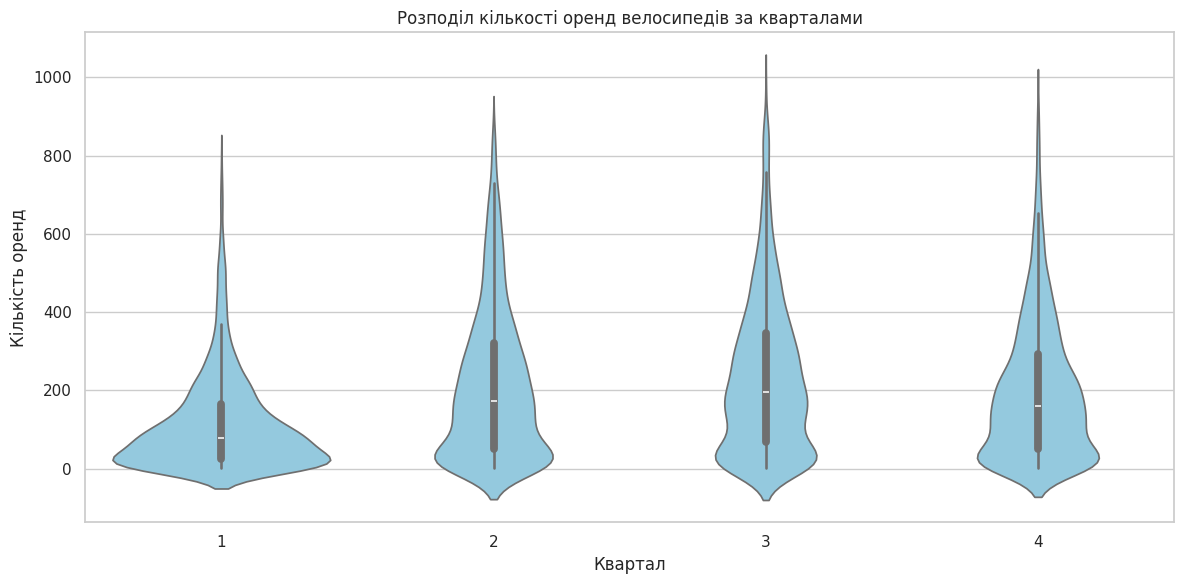

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season', y='count', color='skyblue')
plt.xticks(rotation=0)
plt.title('Розподіл кількості оренд велосипедів за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')

plt.tight_layout()
plt.show()

**Відповідь:** **1.** Що показує "товщина" violin plot?
Товщина показує щільність розподілу даних.
Широка частина - у цьому діапазоні значень багато спостережень.
Вузька частина - значень мало.
Тобто ширина показує, де найчастіше зустрічаються значення кількості оренд велосипедів. **2**.В якому кварталі найбільша варіабельність оренди?
Визначається за висотою «скрипки» (діапазоном значень), наявністю кількох потовщень, великим розкидом даних. Найбільша варіабельність  спостерігається в 3 та 4 кварталі, оскільки в теплі сезони кількість оренд сильно змінюється і може досягати дуже високих значень. Графік є найвищим та найширшим у 4 кварталі — саме цей квартал має найбільшу варіабельність. **3.** Яка перевага violin plot над звичайним box plot?
Box plot показує лише: медіану, квартилі, розмах, викиди.
Violin plot ще показує і форму розподілу даних: де значення концентруються,
чи є  піки, чи розподіл симетричний, чи є довгі «хвости».
Box plot відповідає на питання «наскільки розкидані дані», а violin plot — «як саме вони розподілені всередині цього діапазону».

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

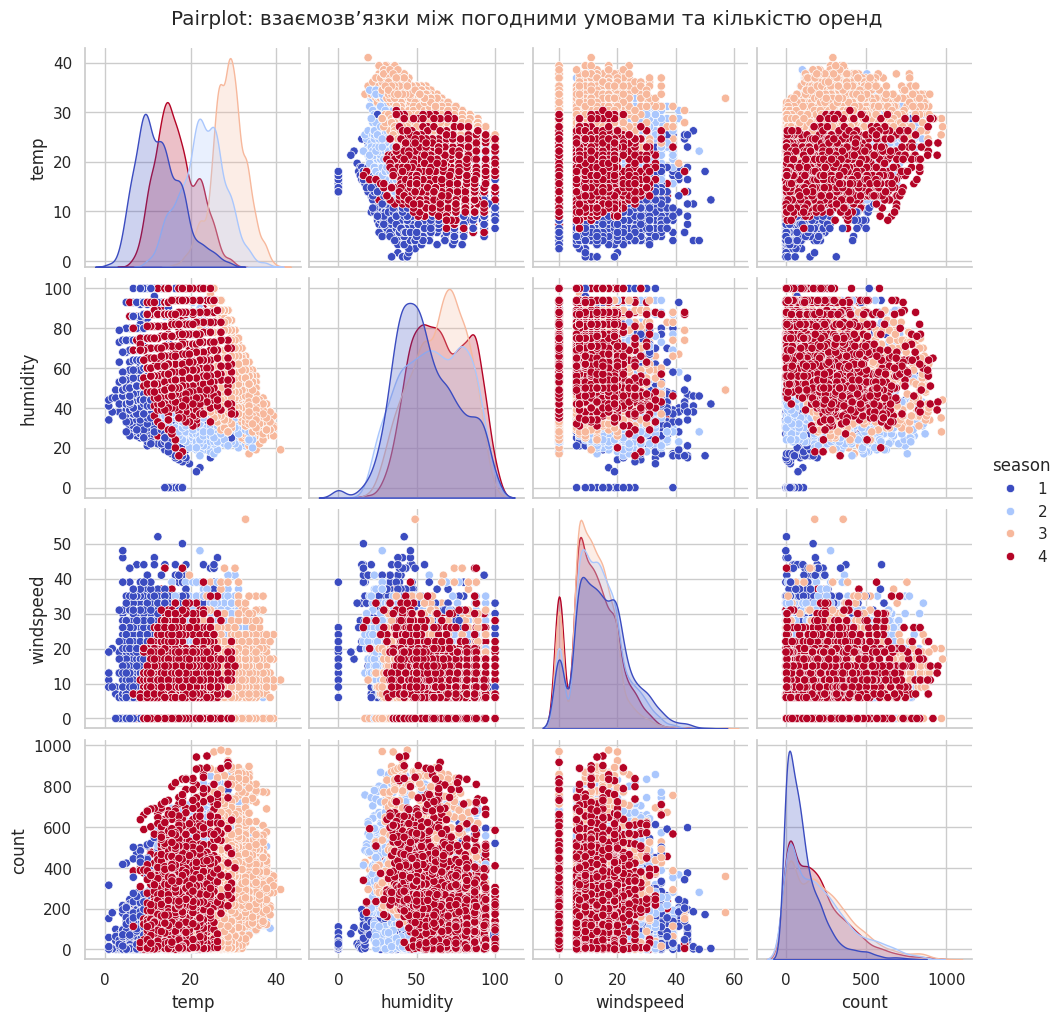

In [ ]:
sns.pairplot(
    data=df,
    vars=['temp', 'humidity', 'windspeed', 'count'],
    hue='season',
    palette='coolwarm',
   # diag_kind='hist',   # гістограми на діагоналі
    corner=False           # показати лише нижню половину матриці True
)
plt.suptitle('Pairplot: взаємозв’язки між погодними умовами та кількістю оренд', y=1.02)
plt.show();

**Відповідь:** **1.** Між якими змінними спостерігається найсильніший лінійний зв'язок? Найсильніший лінійний зв'язок спостерігається між:
temp і count — помірний або сильний позитивний зв'язок.
На scatter-графіку це виглядає як хмара точок, що піднімається зліва направо:чим вища температура, тим більше людей орендує велосипеди.
**2.** Яка характеристика найбільше відрізняється між кварталами?
Найбільше між кварталами відрізняється температура (temp).
На pairplot видно, що точки різних кварталів утворюють окремі кластери:
холодні квартали мають низькі значення temp,теплі квартали — високі значення temp. Кількість оренд (count) також помітно відрізняється між сезонами, але саме температура найчастіше дає найчіткіше розділення кольорових груп.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

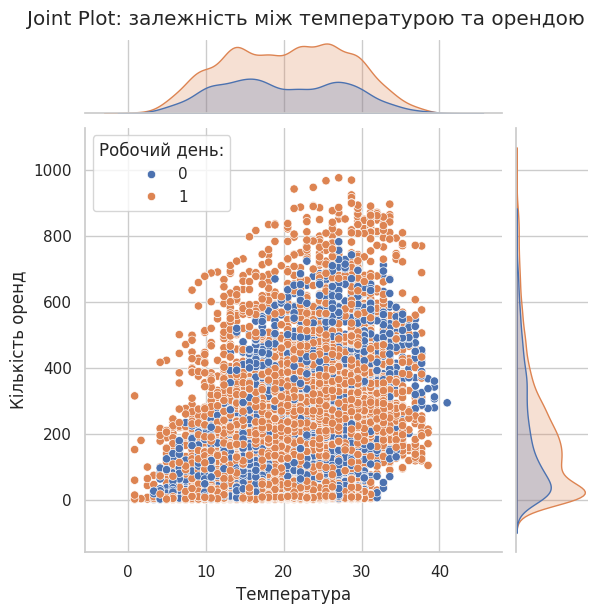

In [ ]:
sns.jointplot(data=df, x="temp",
              y="count",
              hue="workingday"#,
              #hue_order=("Вихідний", "Робочий")
              )
plt.suptitle('Joint Plot: залежність між температурою та орендою', y=1.02)
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')
plt.legend(title='Робочий день:')
plt.show();

**Відповідь:** **1.** Що показують графіки по краях? -
Графіки по краях (marginal plots) показують одновимірний розподіл кожної змінної окремо: верхній графік показує розподіл температури (temp), правий графік показує розподіл кількості оренд (count).
Вони дозволяють побачити: де зосереджена більшість значень, чи є піки розподілу, наскільки широкий діапазон значень, чи є асиметрія або кілька груп спостережень. Основний центральний графік показує зв'язок між двома змінними, а крайові графіки допомагають зрозуміти розподіл кожної змінної окремо. **2.** Чи є різниця у поведінці користувачів у робочий і неробочий день? -
Різниця є. На joint plot можна побачити, що
в обох групах зі зростанням температури кількість оренд збільшується,
у робочі дні (workingday = 1) спостерігається більша концентрація точок у зоні високих значень count, тобто велосипеди орендують частіше, а у неробочі дні (workingday = 0) кількість оренд більш розсіяна і приймає нижчі значення.